
# Direct injection/fiducial waveform comparison: high-frequency tail of \(h_0\)

This notebook compares the **directly regenerated injection/fiducial detector waveform** \(h_0(f)=h(f;x_{\rm fid})\) across events, focusing on the final high-frequency region before the waveform drops toward numerical zero.

It deliberately **does not instantiate** `RelativeBinningGravitationalWaveTransient` and does **not** evaluate any RB likelihood. It only uses the same event metadata, waveform arguments, EOS-fit conversion, and detector projection to regenerate the fiducial waveform. It also overlays the saved exact detector-frame injection signal, when available, as a consistency check.

Default comparison:

```python
EVENTS = [1, 4, 9]
```

The main purpose is to see whether event 1 and event 4, which had more severe RB failures, show the same kind of high-frequency near-zero structure in the injection/fiducial waveform as event 9.


In [1]:

# =========================================================
# User configuration
# =========================================================
from pathlib import Path

RUNDIR = Path("/scratch/gpfs/ANDREASB/fy6204/GW/Workspace")
SCRIPT_PATH = RUNDIR / "rb_event9_diagnose_fixed.py"

POP_OUTDIR = RUNDIR / "outdir_population_exactfd"
OUTDIR = RUNDIR / "direct_injection_h0_comparison"
PLOT_OUTDIR = OUTDIR / "plots"

EVENTS = [1, 2, 3, 4, 9, 10]

# Must match the original injection/PE convention.
SKY_FRAME = "detector"   # "detector" or "sky"
WIDEN_MC = 0.0002         # only used to construct the same fiducial helper; not used for priors here
DELTA_SIGMA = 1.0         # not important for direct h0 plotting

# High-frequency tail detection.
DROP_SEARCH_MIN_HZ = 800.0
LARGE_DROP_DEX = 3.0      # mark downward jumps in log10|h0| larger than this
ZOOM_BEFORE_HZ = 200.0
ZOOM_AFTER_HZ = 15.0

# If True, use the saved exact detector-frame injection signal to determine the window.
# If False, use the regenerated direct h0.
DETECT_WINDOW_FROM_EXACT_SIGNAL = False

OUTDIR.mkdir(parents=True, exist_ok=True)
PLOT_OUTDIR.mkdir(parents=True, exist_ok=True)
print("Output directory:", OUTDIR)


Output directory: /scratch/gpfs/ANDREASB/fy6204/GW/Workspace/direct_injection_h0_comparison


In [2]:

# =========================================================
# Imports and helper module loading
# =========================================================
import os
import sys
import json
import importlib.util
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import bilby

if not SCRIPT_PATH.exists():
    raise FileNotFoundError(f"Cannot find helper script: {SCRIPT_PATH}")

spec = importlib.util.spec_from_file_location("rbdiag", str(SCRIPT_PATH))
rbdiag = importlib.util.module_from_spec(spec)
sys.modules["rbdiag"] = rbdiag
spec.loader.exec_module(rbdiag)

print("Loaded helper module from", SCRIPT_PATH)
print("bilby version:", getattr(bilby, "__version__", "unknown"))


Loaded helper module from /scratch/gpfs/ANDREASB/fy6204/GW/Workspace/rb_event9_diagnose_fixed.py
bilby version: 2.8.0.dev15+g307b15ae1


In [3]:

# =========================================================
# Direct h0 construction: no RB likelihood is instantiated here
# =========================================================

def build_direct_injection_h0(event_index):
    """
    Build detector-projected injection/fiducial h0 directly from the full
    waveform generator and detector response.

    This does NOT construct RelativeBinningGravitationalWaveTransient.
    It returns both:
      - h0_direct: regenerated detector response from the full waveform generator
      - h0_exact_saved: saved exact detector-frame injection signal from the population file
    """
    event_name = f"event_{event_index:04d}"

    catalog = rbdiag.load_catalog_contract(str(POP_OUTDIR))
    meta, exact_info, signal_path = rbdiag.load_event_meta(str(POP_OUTDIR), event_name)

    inj = dict(meta["injection_parameters"])
    inj["mass_1_detector"] = float(meta["mass_1_detector"])
    inj["mass_2_detector"] = float(meta["mass_2_detector"])

    duration = int(meta["data_segment"]["duration"])
    start_time = float(meta["data_segment"]["start_time"])
    sampling_frequency = float(meta["data_segment"]["sampling_frequency"])
    fmin = float(catalog["fmin"])
    ifo_files = list(catalog["ifo_files"])

    waveform_arguments_full = dict(catalog["waveform_arguments"])
    waveform_arguments_full.pop("frequency_bin_edges", None)
    waveform_arguments_full.pop("fiducial", None)

    exact_freq, exact_sig = rbdiag.load_exact_detector_signals(signal_path, exact_info)

    # Use the same interferometer construction as the diagnostic pipeline so the
    # frequency grid and detector objects are identical. We only use these objects
    # for frequency arrays, masks, PSD metadata, and detector projection.
    ifos = rbdiag.make_interferometers(
        ifo_files=ifo_files,
        fmin=fmin,
        fs=sampling_frequency,
        duration=duration,
        start_time=start_time,
        noise_seed=meta["noise_seed"],
        exact_freq=exact_freq,
        exact_sig=exact_sig,
    )

    _dirty_fid, clean_fid, mc_inj = rbdiag.build_eosfit_fiducials(inj, ifos, SKY_FRAME)
    fid = dict(clean_fid)

    # Direct waveform generation uses the same EOS-fit conversion as PE/RB, but
    # the full LAL BNS source model rather than the relative-binning source model.
    wg_full = bilby.gw.WaveformGenerator(
        duration=duration,
        sampling_frequency=sampling_frequency,
        frequency_domain_source_model=bilby.gw.source.lal_binary_neutron_star,
        parameter_conversion=rbdiag.convert_eosfit_to_lal_bns_for_waveform,
        waveform_arguments=dict(waveform_arguments_full),
    )

    pols = wg_full.frequency_domain_strain(fid)
    if pols is None:
        raise RuntimeError(f"event {event_index}: full waveform generator returned None")

    # Detector response needs sky-frame keys even if the PE sampled zenith/azimuth.
    response_params = dict(fid)
    response_params.setdefault("ra", float(inj["ra"]))
    response_params.setdefault("dec", float(inj["dec"]))
    response_params.setdefault("geocent_time", float(inj["geocent_time"]))
    response_params.setdefault("psi", float(inj["psi"]))

    h0_direct = {}
    h0_exact_saved = {}
    freq = {}
    mask = {}
    psd = {}

    for ifo in ifos:
        name = ifo.name
        freq[name] = np.asarray(ifo.frequency_array)
        mask[name] = np.asarray(ifo.frequency_mask, dtype=bool)
        psd[name] = np.asarray(ifo.power_spectral_density_array)
        h0_direct[name] = np.asarray(ifo.get_detector_response(pols, response_params))
        h0_exact_saved[name] = np.asarray(exact_sig[name])

        if freq[name].shape != h0_direct[name].shape:
            raise RuntimeError(f"event {event_index}, {name}: frequency/waveform shape mismatch")

    return dict(
        event_index=event_index,
        event_name=event_name,
        meta=meta,
        inj=inj,
        ifos=ifos,
        fid=fid,
        waveform_arguments_full=waveform_arguments_full,
        waveform_generator=wg_full,
        pols=pols,
        freq=freq,
        mask=mask,
        psd=psd,
        h0_direct=h0_direct,
        h0_exact_saved=h0_exact_saved,
        exact_freq=np.asarray(exact_freq),
        mc_inj=float(mc_inj),
    )


In [4]:

# =========================================================
# High-frequency drop detection helpers
# =========================================================

def detect_h0_drops(f, h, mask, search_min_hz=DROP_SEARCH_MIN_HZ, large_drop_dex=LARGE_DROP_DEX):
    """
    Detect high-frequency downward jumps in log10|h|.

    The default selected cutoff is the last large downward jump. This is useful
    for plotting the final ~200 Hz before the waveform approaches numerical zero.
    """
    y = np.abs(h)
    m = mask & np.isfinite(f) & np.isfinite(y) & (y > 0.0) & (f >= search_min_hz)
    ff = f[m]
    yy = y[m]

    if len(ff) < 5:
        return dict(
            ok=False,
            reason="not enough valid high-frequency points",
            drop_freqs=np.array([]),
            drop_dex=np.array([]),
            f_cut=np.nan,
            f_left=np.nan,
            f_right=np.nan,
            min_abs_h=np.nan,
            f_min_abs_h=np.nan,
            max_drop_dex=np.nan,
            f_max_drop=np.nan,
        )

    logy = np.log10(np.maximum(yy, 1e-300))
    dlog = np.diff(logy)
    drop_size = -dlog

    large = drop_size >= large_drop_dex
    drop_freqs = ff[1:][large]
    drop_dex = drop_size[large]

    i_big = int(np.nanargmax(drop_size))
    f_big = float(ff[1:][i_big])
    max_drop = float(drop_size[i_big])

    if len(drop_freqs) > 0:
        f_cut = float(np.max(drop_freqs))
    else:
        f_cut = f_big

    f_left = max(float(ff[0]), f_cut - ZOOM_BEFORE_HZ)
    f_right = min(float(ff[-1]), f_cut + ZOOM_AFTER_HZ)

    i_min = int(np.nanargmin(yy))

    return dict(
        ok=True,
        reason="",
        drop_freqs=drop_freqs,
        drop_dex=drop_dex,
        f_cut=f_cut,
        f_left=f_left,
        f_right=f_right,
        min_abs_h=float(yy[i_min]),
        f_min_abs_h=float(ff[i_min]),
        max_drop_dex=max_drop,
        f_max_drop=f_big,
    )


def choose_window_signal(event_data, ifo_name):
    if DETECT_WINDOW_FROM_EXACT_SIGNAL:
        return event_data["h0_exact_saved"][ifo_name]
    return event_data["h0_direct"][ifo_name]


def direct_event_ifo_summary(event_data):
    rows = []
    for ifo in event_data["ifos"]:
        name = ifo.name
        f = event_data["freq"][name]
        mask = event_data["mask"][name]
        h_dir = event_data["h0_direct"][name]
        h_exact = event_data["h0_exact_saved"][name]
        h_for_window = choose_window_signal(event_data, name)
        det = detect_h0_drops(f, h_for_window, mask)

        m = mask & np.isfinite(f) & np.isfinite(h_dir) & np.isfinite(h_exact)
        rel = np.full_like(f, np.nan, dtype=float)
        good = m & (np.abs(h_exact) > 1e-300)
        rel[good] = np.abs(h_dir[good] - h_exact[good]) / np.abs(h_exact[good])

        m1 = float(event_data["inj"]["mass_1_detector"])
        m2 = float(event_data["inj"]["mass_2_detector"])
        rows.append(dict(
            event=event_data["event_index"],
            ifo=name,
            ok=det["ok"],
            f_cut=det["f_cut"],
            f_max_drop=det["f_max_drop"],
            max_drop_dex=det["max_drop_dex"],
            n_large_drops=len(det["drop_freqs"]),
            f_first_large_drop=float(det["drop_freqs"][0]) if len(det["drop_freqs"]) else np.nan,
            f_last_large_drop=float(det["drop_freqs"][-1]) if len(det["drop_freqs"]) else np.nan,
            min_abs_h=det["min_abs_h"],
            f_min_abs_h=det["f_min_abs_h"],
            max_direct_exact_relerr=float(np.nanmax(rel[good])) if np.any(good) else np.nan,
            median_direct_exact_relerr=float(np.nanmedian(rel[good])) if np.any(good) else np.nan,
            mc_inj=event_data["mc_inj"],
            m1_det=m1,
            m2_det=m2,
            q_inj=min(m1, m2) / max(m1, m2),
            dL=float(event_data["inj"]["luminosity_distance"]),
        ))
    return rows


In [5]:

# =========================================================
# Build direct h0 for all requested events
# =========================================================

events_data = {}
summary_rows = []

for ev in EVENTS:
    print(f"\nBuilding direct injection h0 for event {ev} ...")
    try:
        ed = build_direct_injection_h0(ev)
        events_data[ev] = ed
        summary_rows.extend(direct_event_ifo_summary(ed))
        print(f"  built {ed['event_name']}: duration={ed['meta']['data_segment']['duration']}, fs={ed['meta']['data_segment']['sampling_frequency']}")
    except Exception as exc:
        print(f"  FAILED event {ev}: {exc}")
        summary_rows.append(dict(event=ev, ifo="ERROR", ok=False, reason=str(exc)))

summary_df = pd.DataFrame(summary_rows)
display(summary_df)
summary_path = OUTDIR / "direct_h0_high_frequency_drop_summary.csv"
summary_df.to_csv(summary_path, index=False)
print("Wrote", summary_path)



Building direct injection h0 for event 1 ...


00:11 bilby INFO    : Waveform generator instantiated: WaveformGenerator(duration=1024, sampling_frequency=8192.0, start_time=0, frequency_domain_source_model=bilby.gw.source.lal_binary_neutron_star, time_domain_source_model=None, parameter_conversion=rbdiag.convert_eosfit_to_lal_bns_for_waveform, waveform_arguments={'minimum_frequency': 10.0, 'reference_frequency': 10.0, 'waveform_approximant': 'IMRPhenomXP_NRTidalv3'})
/home/fy6204/.conda/envs/GW/lib/python3.11/site-packages/lalsimulation/lalsimulation.py:8: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

imp

  built event_0001: duration=1024, fs=8192.0

Building direct injection h0 for event 2 ...


00:11 bilby INFO    : Waveform generator instantiated: WaveformGenerator(duration=1024, sampling_frequency=8192.0, start_time=0, frequency_domain_source_model=bilby.gw.source.lal_binary_neutron_star, time_domain_source_model=None, parameter_conversion=rbdiag.convert_eosfit_to_lal_bns_for_waveform, waveform_arguments={'minimum_frequency': 10.0, 'reference_frequency': 10.0, 'waveform_approximant': 'IMRPhenomXP_NRTidalv3'})


  built event_0002: duration=1024, fs=8192.0

Building direct injection h0 for event 3 ...


...

  built event_0009: duration=1024, fs=8192.0

Building direct injection h0 for event 10 ...


00:11 bilby INFO    : Waveform generator instantiated: WaveformGenerator(duration=1024, sampling_frequency=8192.0, start_time=0, frequency_domain_source_model=bilby.gw.source.lal_binary_neutron_star, time_domain_source_model=None, parameter_conversion=rbdiag.convert_eosfit_to_lal_bns_for_waveform, waveform_arguments={'minimum_frequency': 10.0, 'reference_frequency': 10.0, 'waveform_approximant': 'IMRPhenomXP_NRTidalv3'})


  built event_0010: duration=1024, fs=8192.0


,event,ifo,ok,f_cut,f_max_drop,max_drop_dex,n_large_drops,f_first_large_drop,f_last_large_drop,min_abs_h,f_min_abs_h,max_direct_exact_relerr,median_direct_exact_relerr,mc_inj,m1_det,m2_det,q_inj,dL
0,1,CE-B20,True,1790.699219,1790.699219,4.730621,1,1790.699219,1790.699219,2.883231e-47,1800.087891,0.068486,0.002616,1.292819,1.518223,1.452760,0.956882,849.002290
1,1,CE-A40,True,1790.699219,1790.699219,4.730621,1,1790.699219,1790.699219,1.049051e-47,1800.087891,0.068486,0.002616,1.292819,1.518223,1.452760,0.956882,849.002290
2,2,CE-B20,True,1580.366211,1580.366211,0.301030,0,NaN,NaN,5.951861e-40,1580.366211,0.252886,0.004525,1.405936,1.711614,1.524849,0.890884,1471.537834
3,2,CE-A40,True,1580.366211,1580.366211,0.301030,0,NaN,NaN,2.866631e-40,1580.366211,0.252886,0.004525,1.405936,1.711614,1.524849,0.890884,1471.537834
4,3,CE-B20,True,1503.916992,1503.916992,0.301030,0,NaN,NaN,3.413668e-39,1503.916992,0.159552,0.004878,1.348438,1.727877,1.391795,0.805495,1185.362726
5,3,CE-A40,True,1503.916992,1503.916992,0.301030,0,NaN,NaN,5.473953e-39,1503.916992,0.159552,0.004878,1.348438,1.727877,1.391795,0.805495,1185.362726
6,4,CE-B20,True,1717.187500,1717.187500,4.395595,1,1717.187500,1717.187500,1.980032e-46,1726.816406,0.250342,0.001782,1.332654,1.640400,1.429903,0.871679,875.443197
7,4,CE-A40,True,1717.187500,1717.187500,4.395596,1,1717.187500,1717.187500,3.401119e-46,1726.816406,0.250342,0.001782,1.332654,1.640400,1.429903,0.871679,875.443197
8,9,CE-B20,True,1876.813477,1876.813477,4.024919,1,1876.813477,1876.813477,2.278894e-46,1886.695312,0.166866,0.001453,1.374822,1.648747,1.513250,0.917818,705.241437
9,9,CE-A40,True,1876.813477,1876.813477,4.024919,1,1876.813477,1876.813477,3.697854e-46,1886.695312,0.166866,0.001453,1.374822,1.648747,1.513250,0.917818,705.241437


Wrote /scratch/gpfs/ANDREASB/fy6204/GW/Workspace/direct_injection_h0_comparison/direct_h0_high_frequency_drop_summary.csv


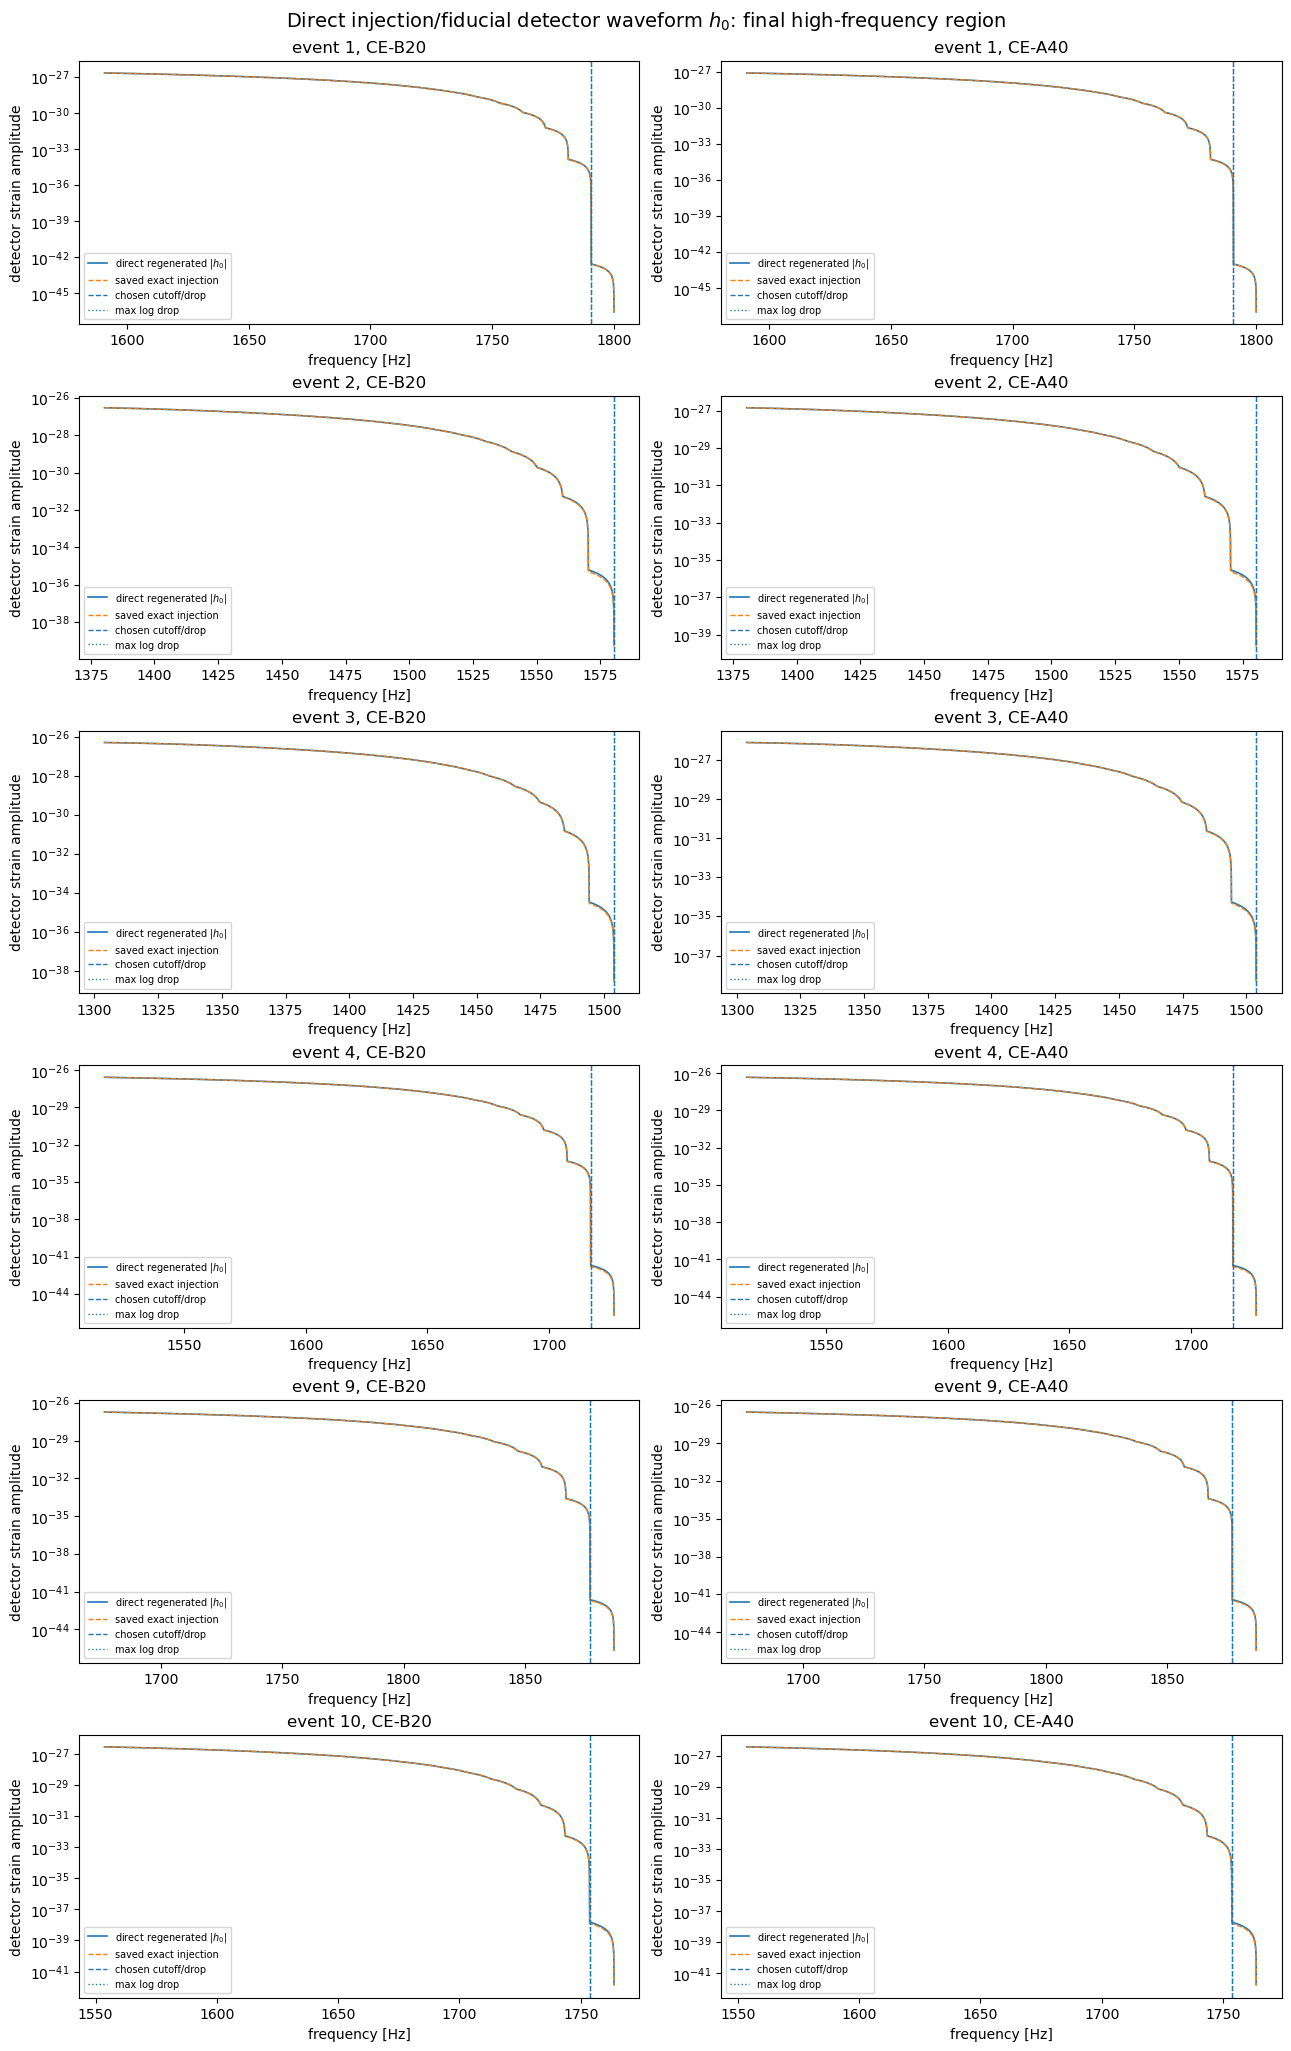

,event,ifo,f_left,f_right,f_cut,f_max_drop,max_drop_dex,min_abs_h,f_min_abs_h,n_large_drops
0,1,CE-B20,1590.699219,1800.087891,1790.699219,1790.699219,4.730621,2.883231e-47,1800.087891,1
1,1,CE-A40,1590.699219,1800.087891,1790.699219,1790.699219,4.730621,1.049051e-47,1800.087891,1
2,2,CE-B20,1380.366211,1580.366211,1580.366211,1580.366211,0.301030,5.951861e-40,1580.366211,0
3,2,CE-A40,1380.366211,1580.366211,1580.366211,1580.366211,0.301030,2.866631e-40,1580.366211,0
4,3,CE-B20,1303.916992,1503.916992,1503.916992,1503.916992,0.301030,3.413668e-39,1503.916992,0
5,3,CE-A40,1303.916992,1503.916992,1503.916992,1503.916992,0.301030,5.473953e-39,1503.916992,0
6,4,CE-B20,1517.187500,1726.816406,1717.187500,1717.187500,4.395595,1.980032e-46,1726.816406,1
7,4,CE-A40,1517.187500,1726.816406,1717.187500,1717.187500,4.395596,3.401119e-46,1726.816406,1
8,9,CE-B20,1676.813477,1886.695312,1876.813477,1876.813477,4.024919,2.278894e-46,1886.695312,1
9,9,CE-A40,1676.813477,1886.695312,1876.813477,1876.813477,4.024919,3.697854e-46,1886.695312,1


Saved figure: /scratch/gpfs/ANDREASB/fy6204/GW/Workspace/direct_injection_h0_comparison/plots/direct_h0_last200Hz_by_event_detector.png
Wrote /scratch/gpfs/ANDREASB/fy6204/GW/Workspace/direct_injection_h0_comparison/direct_h0_last200Hz_plot_windows.csv


In [6]:

# =========================================================
# Figure 1: direct h0 and saved exact injection signal in the final ~200 Hz
# Rows: events. Columns: detectors.
# =========================================================

valid_events = [ev for ev in EVENTS if ev in events_data]
if not valid_events:
    raise RuntimeError("No events were built successfully")

ifo_names = [ifo.name for ifo in events_data[valid_events[0]]["ifos"]]

fig, axes = plt.subplots(
    len(valid_events), len(ifo_names),
    figsize=(6.4 * len(ifo_names), 3.4 * len(valid_events)),
    sharex=False,
    sharey=False,
    squeeze=False,
    constrained_layout=True,
)

plot_rows = []

for i, ev in enumerate(valid_events):
    ed = events_data[ev]
    for j, name in enumerate(ifo_names):
        ax = axes[i, j]
        f = ed["freq"][name]
        mask = ed["mask"][name]
        h_dir = ed["h0_direct"][name]
        h_exact = ed["h0_exact_saved"][name]
        det = detect_h0_drops(f, choose_window_signal(ed, name), mask)

        if not det["ok"]:
            ax.text(0.5, 0.5, det["reason"], ha="center", va="center", transform=ax.transAxes)
            continue

        m = mask & np.isfinite(f) & (f >= det["f_left"]) & (f <= det["f_right"])

        ax.semilogy(f[m], np.abs(h_dir[m]), lw=1.2, label=r"direct regenerated $|h_0|$")
        ax.semilogy(f[m], np.abs(h_exact[m]), lw=1.0, ls="--", label="saved exact injection")
        ax.axvline(det["f_cut"], ls="--", lw=1.0, label="chosen cutoff/drop")
        ax.axvline(det["f_max_drop"], ls=":", lw=1.0, label="max log drop")

        for fd in det["drop_freqs"]:
            if det["f_left"] <= fd <= det["f_right"]:
                ax.axvline(fd, lw=0.4, alpha=0.22)

        ax.set_title(f"event {ev}, {name}")
        ax.set_xlabel("frequency [Hz]")
        ax.set_ylabel("detector strain amplitude")
        ax.legend(fontsize=7, loc="best")

        plot_rows.append(dict(
            event=ev,
            ifo=name,
            f_left=det["f_left"],
            f_right=det["f_right"],
            f_cut=det["f_cut"],
            f_max_drop=det["f_max_drop"],
            max_drop_dex=det["max_drop_dex"],
            min_abs_h=det["min_abs_h"],
            f_min_abs_h=det["f_min_abs_h"],
            n_large_drops=len(det["drop_freqs"]),
        ))

fig.suptitle(
    r"Direct injection/fiducial detector waveform $h_0$: final high-frequency region",
    fontsize=14,
)

path = PLOT_OUTDIR / "direct_h0_last200Hz_by_event_detector.png"
fig.savefig(path, dpi=200)
plt.show()

plot_window_df = pd.DataFrame(plot_rows)
display(plot_window_df)
plot_window_path = OUTDIR / "direct_h0_last200Hz_plot_windows.csv"
plot_window_df.to_csv(plot_window_path, index=False)
print("Saved figure:", path)
print("Wrote", plot_window_path)


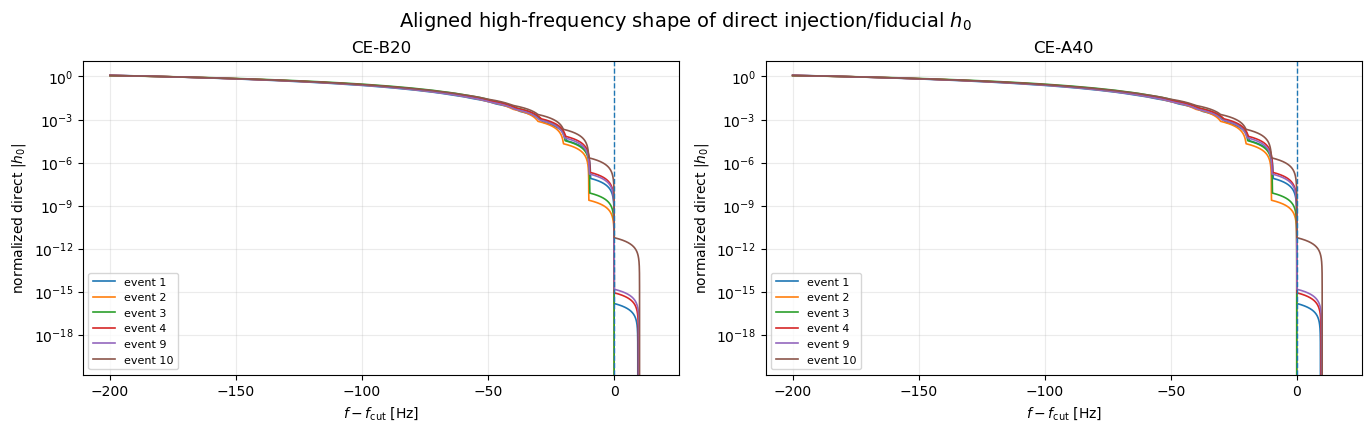

Saved figure: /scratch/gpfs/ANDREASB/fy6204/GW/Workspace/direct_injection_h0_comparison/plots/direct_h0_aligned_last200Hz_overlay.png


In [7]:

# =========================================================
# Figure 2: aligned overlay by detector
# x-axis = frequency relative to each event's detected cutoff/drop.
# This makes events 1/4/9 easy to compare directly.
# =========================================================

fig, axes = plt.subplots(
    1, len(ifo_names),
    figsize=(6.8 * len(ifo_names), 4.2),
    sharey=False,
    constrained_layout=True,
)
if len(ifo_names) == 1:
    axes = [axes]

for j, name in enumerate(ifo_names):
    ax = axes[j]
    for ev in valid_events:
        ed = events_data[ev]
        f = ed["freq"][name]
        mask = ed["mask"][name]
        h = ed["h0_direct"][name]
        det = detect_h0_drops(f, choose_window_signal(ed, name), mask)
        if not det["ok"]:
            continue

        x = f - det["f_cut"]
        m = mask & np.isfinite(f) & np.isfinite(h) & (x >= -ZOOM_BEFORE_HZ) & (x <= ZOOM_AFTER_HZ)
        y = np.abs(h)

        norm_region = m & (x >= -ZOOM_BEFORE_HZ) & (x <= -0.8 * ZOOM_BEFORE_HZ) & (y > 0)
        if np.sum(norm_region) > 3:
            norm = np.nanmedian(y[norm_region])
        else:
            norm = np.nanmax(y[m])
        norm = norm if np.isfinite(norm) and norm > 0 else 1.0

        ax.semilogy(x[m], y[m] / norm, lw=1.2, label=f"event {ev}")

    ax.axvline(0.0, ls="--", lw=1.0)
    ax.set_title(name)
    ax.set_xlabel(r"$f - f_{\rm cut}$ [Hz]")
    ax.set_ylabel(r"normalized direct $|h_0|$")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.25)

fig.suptitle(r"Aligned high-frequency shape of direct injection/fiducial $h_0$", fontsize=14)
path = PLOT_OUTDIR / "direct_h0_aligned_last200Hz_overlay.png"
fig.savefig(path, dpi=200)
plt.show()
print("Saved figure:", path)


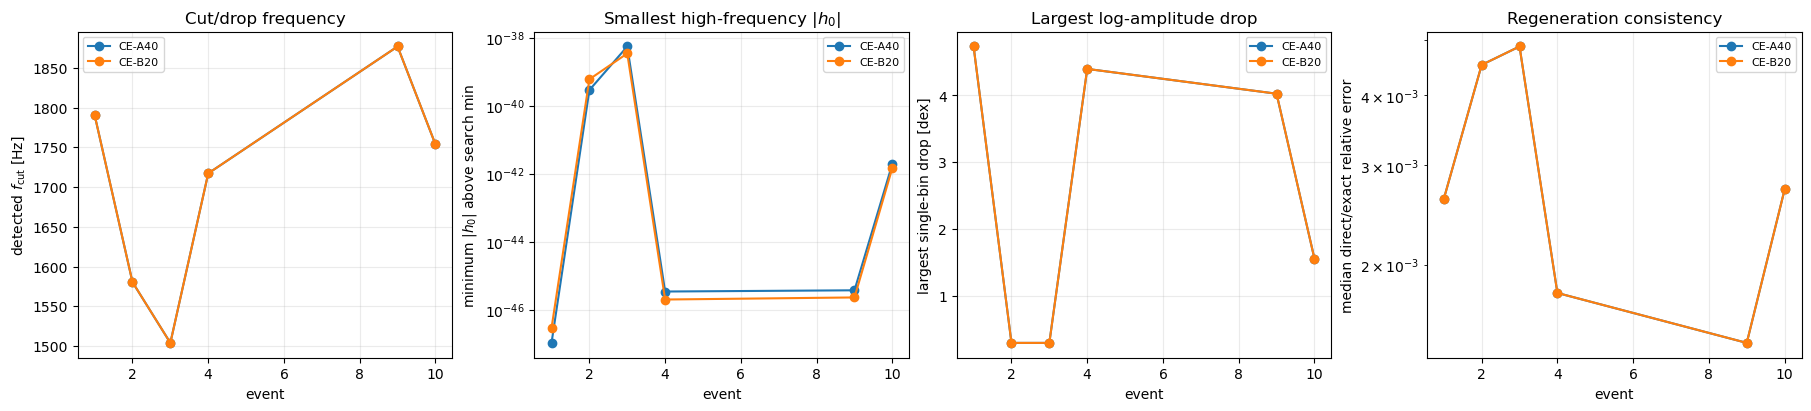

Saved figure: /scratch/gpfs/ANDREASB/fy6204/GW/Workspace/direct_injection_h0_comparison/plots/direct_h0_event_metrics.png


In [8]:

# =========================================================
# Figure 3: compact event-level metrics
# =========================================================

metric_df = summary_df.copy()
metric_df = metric_df[metric_df.get("ifo", "") != "ERROR"].copy()

if len(metric_df):
    fig, axes = plt.subplots(1, 4, figsize=(18, 4), constrained_layout=True)

    for ifo_name, g in metric_df.groupby("ifo"):
        axes[0].plot(g["event"], g["f_cut"], marker="o", label=ifo_name)
        axes[1].semilogy(g["event"], g["min_abs_h"], marker="o", label=ifo_name)
        axes[2].plot(g["event"], g["max_drop_dex"], marker="o", label=ifo_name)
        axes[3].semilogy(g["event"], g["median_direct_exact_relerr"], marker="o", label=ifo_name)

    axes[0].set_xlabel("event")
    axes[0].set_ylabel(r"detected $f_{\rm cut}$ [Hz]")
    axes[0].set_title("Cut/drop frequency")

    axes[1].set_xlabel("event")
    axes[1].set_ylabel(r"minimum $|h_0|$ above search min")
    axes[1].set_title(r"Smallest high-frequency $|h_0|$")

    axes[2].set_xlabel("event")
    axes[2].set_ylabel("largest single-bin drop [dex]")
    axes[2].set_title("Largest log-amplitude drop")

    axes[3].set_xlabel("event")
    axes[3].set_ylabel("median direct/exact relative error")
    axes[3].set_title("Regeneration consistency")

    for ax in axes:
        ax.legend(fontsize=8)
        ax.grid(alpha=0.25)

    path = PLOT_OUTDIR / "direct_h0_event_metrics.png"
    fig.savefig(path, dpi=200)
    plt.show()
    print("Saved figure:", path)
else:
    print("No valid metric rows to plot")


In [9]:

# =========================================================
# Optional: source polarization check
# This helps distinguish waveform-model high-frequency termination from
# detector-response cancellation.
# =========================================================
RUN_POLARIZATION_CHECK = False

if RUN_POLARIZATION_CHECK:
    fig, axes = plt.subplots(
        len(valid_events), 1,
        figsize=(8.0, 3.3 * len(valid_events)),
        squeeze=False,
        constrained_layout=True,
    )

    for i, ev in enumerate(valid_events):
        ed = events_data[ev]
        name0 = ifo_names[0]
        det = detect_h0_drops(ed["freq"][name0], choose_window_signal(ed, name0), ed["mask"][name0])
        f = ed["waveform_generator"].frequency_array
        pols = ed["pols"]

        ax = axes[i, 0]
        m = np.isfinite(f) & (f >= det["f_left"]) & (f <= det["f_right"])
        for key, val in pols.items():
            ax.semilogy(f[m], np.abs(val[m]), label=f"|h_{key}|")
        ax.axvline(det["f_cut"], ls="--", lw=1.0)
        ax.set_title(f"event {ev}: source polarizations near detector h0 cutoff")
        ax.set_xlabel("frequency [Hz]")
        ax.set_ylabel("polarization amplitude")
        ax.legend(fontsize=8)

    path = PLOT_OUTDIR / "direct_h0_source_polarizations_optional.png"
    fig.savefig(path, dpi=200)
    plt.show()
    print("Saved figure:", path)
else:
    print("Set RUN_POLARIZATION_CHECK = True to run this optional check.")


Set RUN_POLARIZATION_CHECK = True to run this optional check.
